# ByteTrack Tracker - Optuna Hyperparameter Search Analysis

This notebook analyzes the hyperparameter optimization results for the ByteTrack tracker.
We explore the relationship between hyperparameters (`track_thresh`, `track_buffer`, `match_thresh`) and the tracking metrics (HOTA, IDF1).

In [2]:
import sqlite3
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from mpl_toolkits.mplot3d import Axes3D
import plotly.graph_objects as go
import plotly.express as px
from plotly.subplots import make_subplots

%matplotlib inline
sns.set_theme(style="whitegrid", palette="muted")

## 1. Load Data from Optuna Database

In [3]:
# Connect to Optuna database
DB_PATH = "../results/studies/optimization.db"
STUDY_NAME = "bytetrack_params_study"

conn = sqlite3.connect(DB_PATH)

# Check available studies
studies = pd.read_sql("SELECT * FROM studies;", conn)
print("Available studies:")
print(studies)
print("\n" + "="*80)

Available studies:
   study_id                    study_name
0         1             sort_params_study
1         2        bytetrack_params_study
2         4           ocsort_params_study
3         5              iou_params_study
4         6  iou_params_study_grid_search



In [4]:
# Load trials for our study
query_trials = f"""
SELECT * FROM trials 
WHERE study_id = (SELECT study_id FROM studies WHERE study_name = '{STUDY_NAME}' LIMIT 1)
"""
df_trials = pd.read_sql(query_trials, conn)

# Load trial parameters
query_params = f"""
SELECT * FROM trial_params 
WHERE trial_id IN (
    SELECT trial_id FROM trials 
    WHERE study_id = (SELECT study_id FROM studies WHERE study_name = '{STUDY_NAME}' LIMIT 1)
)
"""
df_params = pd.read_sql(query_params, conn)

# Load trial values (multi-objective: HOTA and IDF1)
query_values = f"""
SELECT * FROM trial_values 
WHERE trial_id IN (
    SELECT trial_id FROM trials 
    WHERE study_id = (SELECT study_id FROM studies WHERE study_name = '{STUDY_NAME}' LIMIT 1)
)
"""
df_values = pd.read_sql(query_values, conn)

conn.close()

print(f"Total trials: {len(df_trials)}")
print(f"Total parameters: {len(df_params)}")
print(f"Total values: {len(df_values)}")

Total trials: 424
Total parameters: 1272
Total values: 844


## 2. Prepare Data

In [5]:
# Pivot parameters to have one column per parameter
df_params_pivot = df_params.pivot(
    index="trial_id",
    columns="param_name",
    values="param_value"
).reset_index()
df_params_pivot.columns.name = None

# Check df_values structure
print("df_values columns:", df_values.columns.tolist())
print("\ndf_values sample:")
print(df_values.head(10))

# Pivot values to have HOTA and IDF1 as separate columns
if 'objective_id' in df_values.columns:
    df_hota = df_values[df_values['objective_id'] == 0][['trial_id', 'value']].rename(columns={'value': 'HOTA'})
    df_idf1 = df_values[df_values['objective_id'] == 1][['trial_id', 'value']].rename(columns={'value': 'IDF1'})
else:
    print("\nProcessing multi-objective values without objective_id...")
    df_values_sorted = df_values.sort_values('trial_id')
    
    hota_data = []
    idf1_data = []
    
    for trial_id in df_values_sorted['trial_id'].unique():
        trial_values = df_values_sorted[df_values_sorted['trial_id'] == trial_id]['value'].values
        if len(trial_values) >= 2:
            hota_data.append({'trial_id': trial_id, 'HOTA': trial_values[0]})
            idf1_data.append({'trial_id': trial_id, 'IDF1': trial_values[1]})
    
    df_hota = pd.DataFrame(hota_data)
    df_idf1 = pd.DataFrame(idf1_data)
    
    print(f"Extracted {len(df_hota)} HOTA values and {len(df_idf1)} IDF1 values")

print("\n" + "="*80)

# Merge everything
df_results = df_params_pivot.merge(df_hota, on='trial_id').merge(df_idf1, on='trial_id')

# Convert to numeric
df_results['track_thresh'] = pd.to_numeric(df_results['track_thresh'])
df_results['track_buffer'] = pd.to_numeric(df_results['track_buffer'])
df_results['match_thresh'] = pd.to_numeric(df_results['match_thresh'])
df_results['HOTA'] = pd.to_numeric(df_results['HOTA'])
df_results['IDF1'] = pd.to_numeric(df_results['IDF1'])

# Add combined metric
df_results['Combined'] = (df_results['HOTA'] + df_results['IDF1']) / 2

print(f"Prepared {len(df_results)} trials for analysis")
print("\nData shape:", df_results.shape)
print("\nFirst rows:")
df_results.head()

df_values columns: ['trial_value_id', 'trial_id', 'objective', 'value', 'value_type']

df_values sample:
   trial_value_id  trial_id  objective     value value_type
0               5         3          0  0.657453     FINITE
1               6         3          1  0.667045     FINITE
2               9         5          0  0.673146     FINITE
3              10         5          1  0.686154     FINITE
4              13         7          0  0.632361     FINITE
5              14         7          1  0.611063     FINITE
6              17         9          0  0.695059     FINITE
7              18         9          1  0.732599     FINITE
8              21        11          0  0.638408     FINITE
9              22        11          1  0.643636     FINITE

Processing multi-objective values without objective_id...


Extracted 422 HOTA values and 422 IDF1 values

Prepared 422 trials for analysis

Data shape: (422, 7)

First rows:


,trial_id,match_thresh,track_buffer,track_thresh,HOTA,IDF1,Combined
0,3,0.556774,48.0,0.447991,0.657453,0.667045,0.662249
1,5,0.838228,19.0,0.127098,0.673146,0.686154,0.679650
2,7,0.526210,33.0,0.259224,0.632361,0.611063,0.621712
3,9,0.558807,54.0,0.575887,0.695059,0.732599,0.713829
4,11,0.917307,32.0,0.105748,0.638408,0.643636,0.641022


## 3. Overall Statistics

In [6]:
print("="*80)
print("OVERALL STATISTICS")
print("="*80)
print("\nBest results:")
print(f"  Max HOTA: {df_results['HOTA'].max():.4f}")
print(f"  Max IDF1: {df_results['IDF1'].max():.4f}")
print(f"  Max Combined: {df_results['Combined'].max():.4f}")

print("\nBest trial (by HOTA):")
best_hota_idx = df_results['HOTA'].idxmax()
print(df_results.loc[best_hota_idx, ['track_thresh', 'track_buffer', 'match_thresh', 'HOTA', 'IDF1']])

print("\nBest trial (by IDF1):")
best_idf1_idx = df_results['IDF1'].idxmax()
print(df_results.loc[best_idf1_idx, ['track_thresh', 'track_buffer', 'match_thresh', 'HOTA', 'IDF1']])

print("\nBest trial (by Combined):")
best_combined_idx = df_results['Combined'].idxmax()
print(df_results.loc[best_combined_idx, ['track_thresh', 'track_buffer', 'match_thresh', 'HOTA', 'IDF1', 'Combined']])

print("\nParameter ranges:")
print(f"  track_thresh: [{df_results['track_thresh'].min():.2f}, {df_results['track_thresh'].max():.2f}]")
print(f"  track_buffer: [{df_results['track_buffer'].min():.0f}, {df_results['track_buffer'].max():.0f}]")
print(f"  match_thresh: [{df_results['match_thresh'].min():.2f}, {df_results['match_thresh'].max():.2f}]")

OVERALL STATISTICS

Best results:
  Max HOTA: 0.7286
  Max IDF1: 0.8033
  Max Combined: 0.7659

Best trial (by HOTA):
track_thresh     0.685907
track_buffer    60.000000
match_thresh     0.651925
HOTA             0.728559
IDF1             0.803272
Name: 60, dtype: float64

Best trial (by IDF1):
track_thresh     0.685907
track_buffer    60.000000
match_thresh     0.651925
HOTA             0.728559
IDF1             0.803272
Name: 60, dtype: float64

Best trial (by Combined):
track_thresh     0.685907
track_buffer    60.000000
match_thresh     0.651925
HOTA             0.728559
IDF1             0.803272
Combined         0.765915
Name: 60, dtype: float64

Parameter ranges:
  track_thresh: [0.10, 0.70]
  track_buffer: [5, 60]
  match_thresh: [0.50, 0.95]


## 4. Pareto Front Analysis

In [7]:
# Identify Pareto optimal trials
def is_pareto_optimal(costs):
    """Find the pareto-optimal points (for maximization)"""
    is_efficient = np.ones(costs.shape[0], dtype=bool)
    for i, c in enumerate(costs):
        if is_efficient[i]:
            is_efficient[is_efficient] = np.any(costs[is_efficient] >= c, axis=1)
            is_efficient[i] = True
    return is_efficient

# Get Pareto front
costs = df_results[['HOTA', 'IDF1']].values
pareto_mask = is_pareto_optimal(costs)
df_results['is_pareto'] = pareto_mask

pareto_trials = df_results[df_results['is_pareto']]
print(f"\nPareto front contains {len(pareto_trials)} trials")
print("\nPareto optimal trials:")
print(pareto_trials[['trial_id', 'track_thresh', 'track_buffer', 'match_thresh', 'HOTA', 'IDF1']].sort_values('HOTA', ascending=False))


Pareto front contains 3 trials

Pareto optimal trials:
     trial_id  track_thresh  track_buffer  match_thresh      HOTA      IDF1
60        144      0.685907          60.0      0.651925  0.728559  0.803272
284       719      0.685907          60.0      0.651925  0.728559  0.803272
388      1014      0.685907          58.0      0.651925  0.728559  0.803272


## 5. 2D Pareto Front Visualization

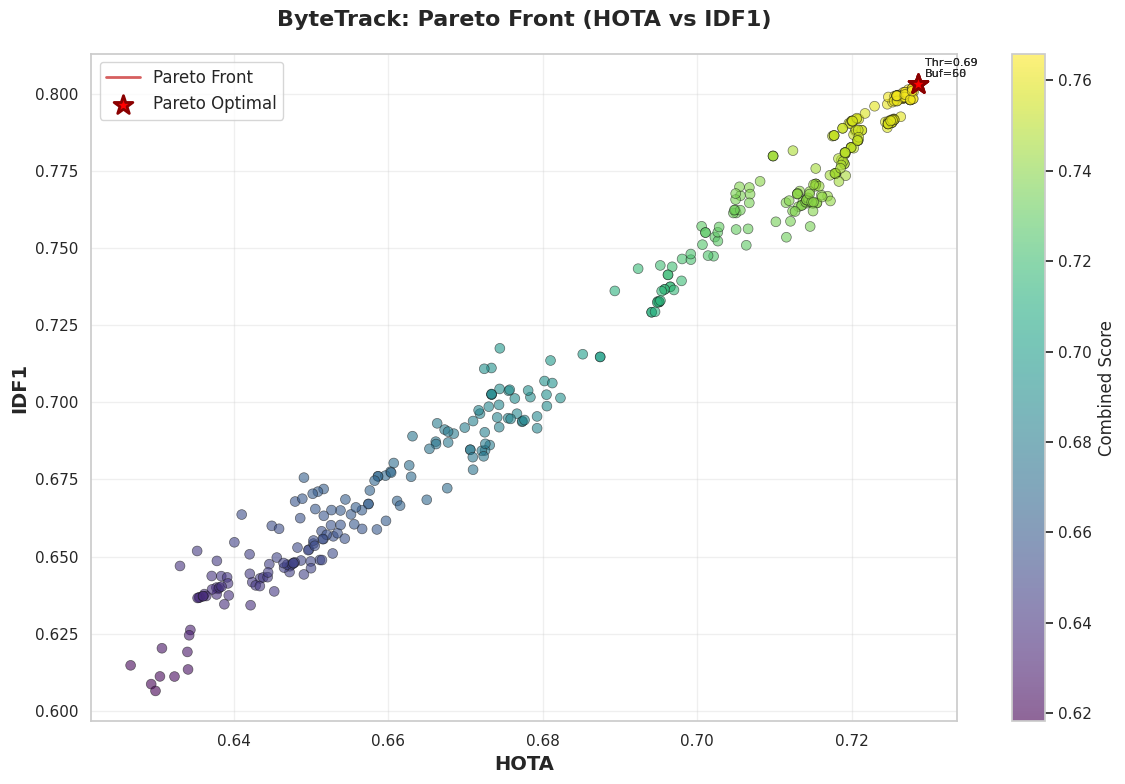

In [8]:
fig, ax = plt.subplots(figsize=(12, 8))

# Plot all trials
scatter = ax.scatter(df_results['HOTA'], df_results['IDF1'], 
                    c=df_results['Combined'], cmap='viridis', 
                    s=50, alpha=0.6, edgecolors='k', linewidth=0.5)

# Highlight Pareto front
pareto_sorted = pareto_trials.sort_values('HOTA')
ax.plot(pareto_sorted['HOTA'], pareto_sorted['IDF1'], 
        'r-', linewidth=2, label='Pareto Front', zorder=5)
ax.scatter(pareto_trials['HOTA'], pareto_trials['IDF1'], 
          c='red', s=200, marker='*', edgecolors='darkred', 
          linewidth=2, label='Pareto Optimal', zorder=6)

# Annotate best trials
for idx, row in pareto_trials.head(5).iterrows():
    ax.annotate(f"Thr={row['track_thresh']:.2f}\nBuf={row['track_buffer']:.0f}", 
                xy=(row['HOTA'], row['IDF1']), 
                xytext=(5, 5), textcoords='offset points',
                fontsize=8, alpha=0.8)

ax.set_xlabel('HOTA', fontsize=14, fontweight='bold')
ax.set_ylabel('IDF1', fontsize=14, fontweight='bold')
ax.set_title('ByteTrack: Pareto Front (HOTA vs IDF1)', fontsize=16, fontweight='bold', pad=20)
ax.legend(fontsize=12)
ax.grid(True, alpha=0.3)

cbar = plt.colorbar(scatter, ax=ax)
cbar.set_label('Combined Score', fontsize=12)

plt.tight_layout()
plt.show()

## 6. Interactive 3D Scatter Plots

In [9]:
# 3D plot: track_thresh vs track_buffer vs HOTA
df_results['Pareto'] = df_results['is_pareto'].map({True: 'Pareto Optimal', False: 'Regular'})

fig = go.Figure()

regular = df_results[~df_results['is_pareto']]
fig.add_trace(go.Scatter3d(
    x=regular['track_thresh'],
    y=regular['track_buffer'],
    z=regular['HOTA'],
    mode='markers',
    name='Regular (HOTA)',
    marker=dict(size=5, color=regular['HOTA'], colorscale='Blues', opacity=0.6, 
                showscale=True, colorbar=dict(x=1.15, title="HOTA")),
    text=[f"Track Thresh: {row['track_thresh']:.2f}<br>Buffer: {row['track_buffer']}<br>Match: {row['match_thresh']:.2f}<br>HOTA: {row['HOTA']:.4f}<br>IDF1: {row['IDF1']:.4f}" 
          for _, row in regular.iterrows()],
    hoverinfo='text'
))

fig.add_trace(go.Scatter3d(
    x=pareto_trials['track_thresh'],
    y=pareto_trials['track_buffer'],
    z=pareto_trials['HOTA'],
    mode='markers',
    name='Pareto Optimal',
    marker=dict(size=10, color='red', symbol='diamond', line=dict(color='darkred', width=2)),
    text=[f"Track Thresh: {row['track_thresh']:.2f}<br>Buffer: {row['track_buffer']}<br>Match: {row['match_thresh']:.2f}<br>HOTA: {row['HOTA']:.4f}<br>IDF1: {row['IDF1']:.4f}" 
          for _, row in pareto_trials.iterrows()],
    hoverinfo='text'
))

fig.update_layout(
    title='3D: track_thresh vs track_buffer vs HOTA',
    scene=dict(xaxis_title='Track Thresh', yaxis_title='Track Buffer', zaxis_title='HOTA',
               camera=dict(eye=dict(x=1.5, y=1.5, z=1.3))),
    width=1000, height=800
)
fig.show()

In [10]:
# 3D plot: match_thresh vs track_buffer vs IDF1
fig = go.Figure()

fig.add_trace(go.Scatter3d(
    x=regular['match_thresh'],
    y=regular['track_buffer'],
    z=regular['IDF1'],
    mode='markers',
    name='Regular (IDF1)',
    marker=dict(size=5, color=regular['IDF1'], colorscale='Greens', opacity=0.6, 
                showscale=True, colorbar=dict(x=1.15, title="IDF1")),
    text=[f"Track Thresh: {row['track_thresh']:.2f}<br>Buffer: {row['track_buffer']}<br>Match: {row['match_thresh']:.2f}<br>HOTA: {row['HOTA']:.4f}<br>IDF1: {row['IDF1']:.4f}" 
          for _, row in regular.iterrows()],
    hoverinfo='text'
))

fig.add_trace(go.Scatter3d(
    x=pareto_trials['match_thresh'],
    y=pareto_trials['track_buffer'],
    z=pareto_trials['IDF1'],
    mode='markers',
    name='Pareto Optimal',
    marker=dict(size=10, color='red', symbol='diamond', line=dict(color='darkred', width=2)),
    text=[f"Track Thresh: {row['track_thresh']:.2f}<br>Buffer: {row['track_buffer']}<br>Match: {row['match_thresh']:.2f}<br>HOTA: {row['HOTA']:.4f}<br>IDF1: {row['IDF1']:.4f}" 
          for _, row in pareto_trials.iterrows()],
    hoverinfo='text'
))

fig.update_layout(
    title='3D: match_thresh vs track_buffer vs IDF1',
    scene=dict(xaxis_title='Match Thresh', yaxis_title='Track Buffer', zaxis_title='IDF1',
               camera=dict(eye=dict(x=1.5, y=1.5, z=1.3))),
    width=1000, height=800
)
fig.show()

## 7. Hyperparameter vs Metrics Analysis

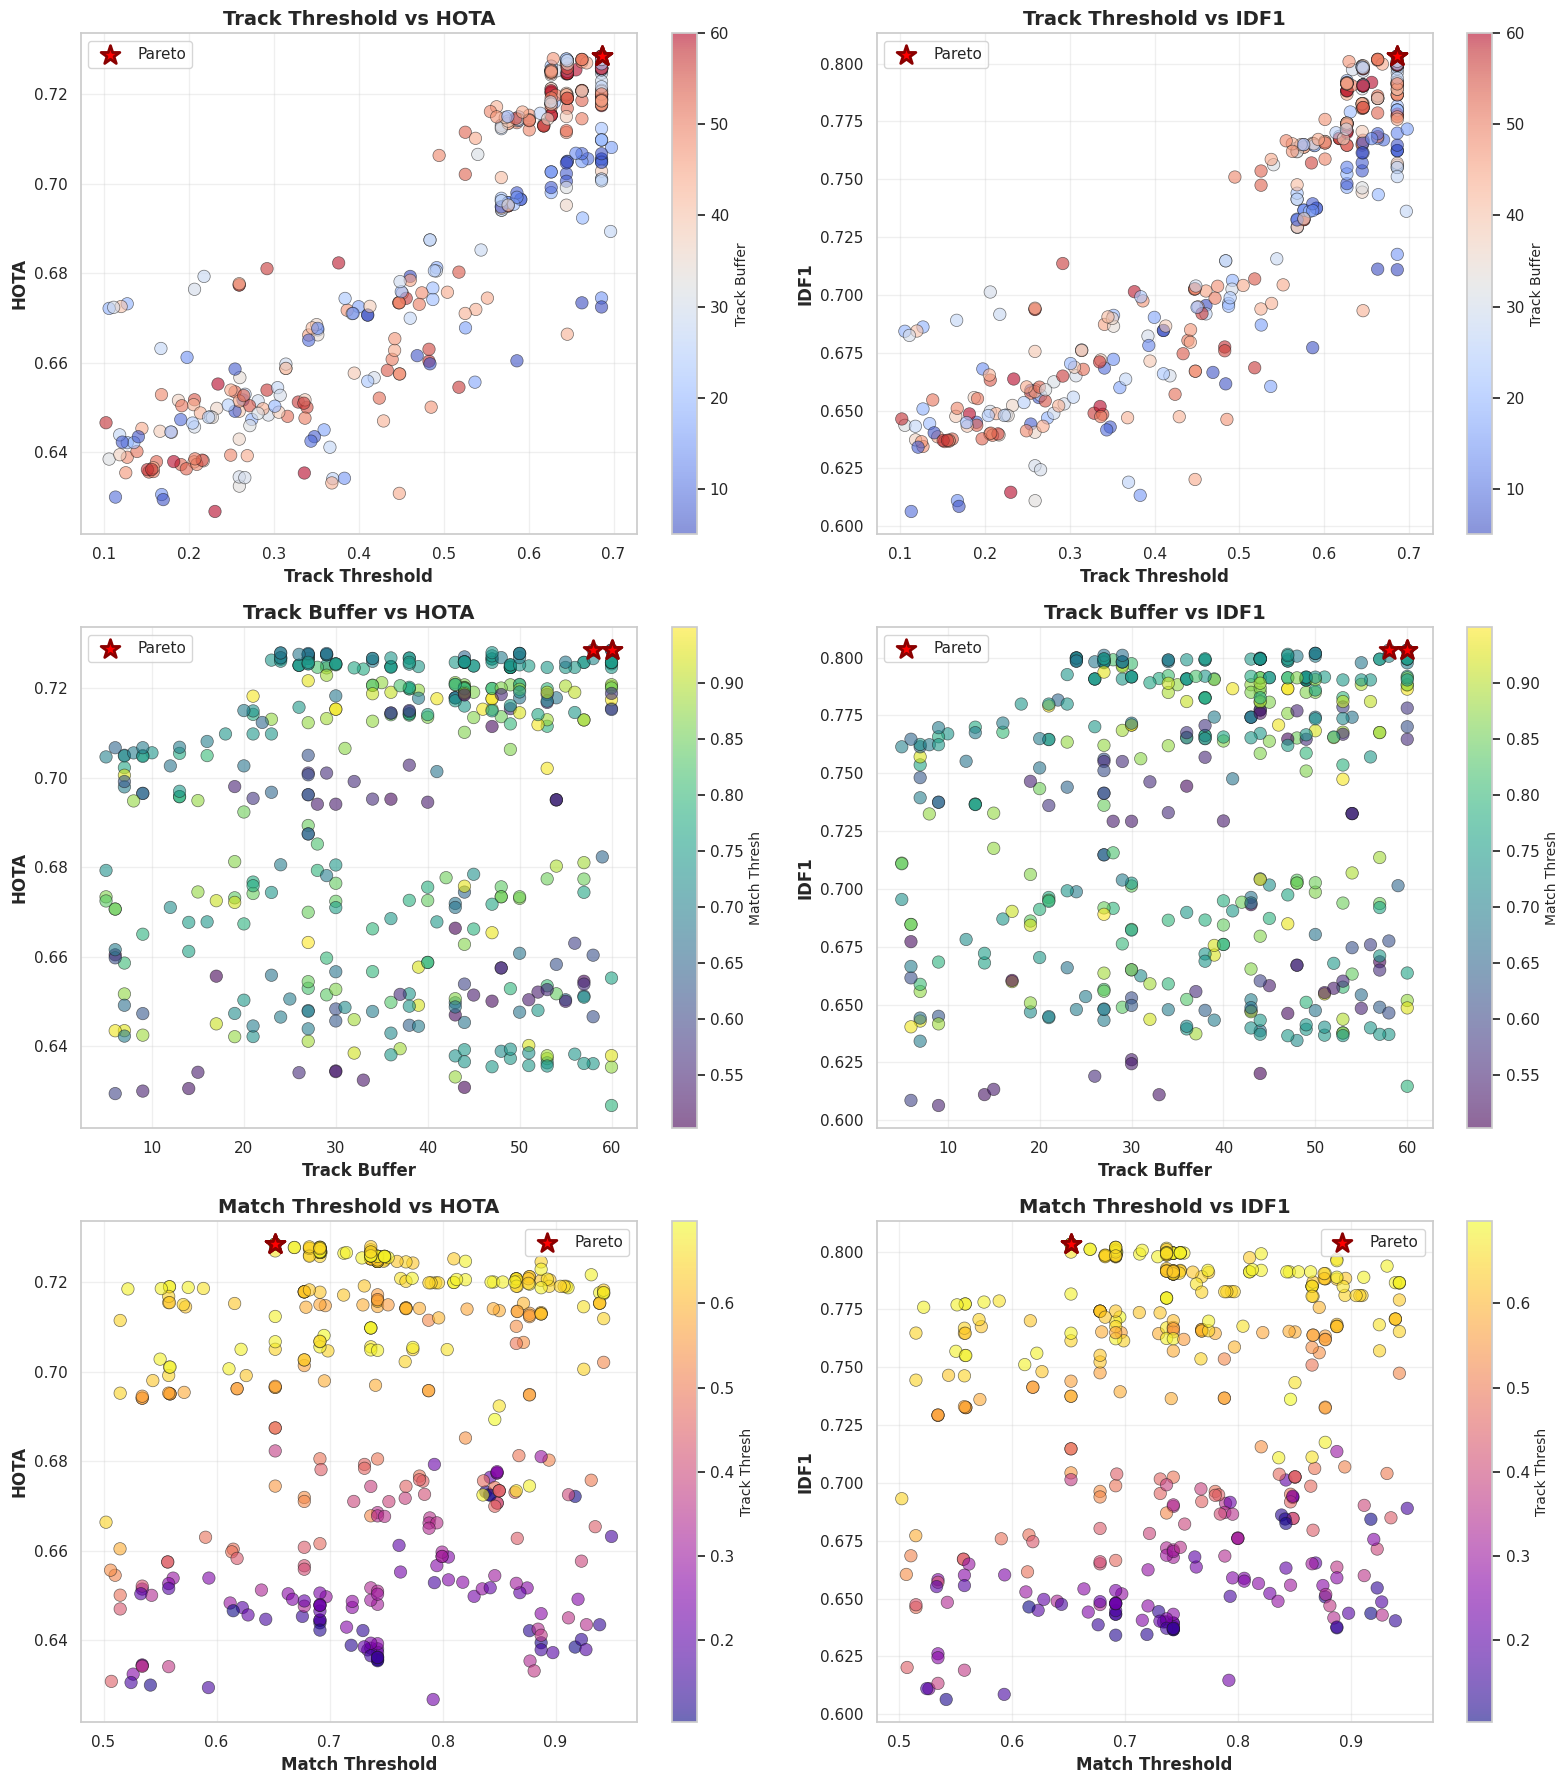

In [11]:
fig, axes = plt.subplots(3, 2, figsize=(16, 18))

# Track Thresh vs HOTA
ax = axes[0, 0]
scatter = ax.scatter(df_results['track_thresh'], df_results['HOTA'], 
                    c=df_results['track_buffer'], cmap='coolwarm', s=80, alpha=0.6, edgecolors='k', linewidth=0.5)
ax.scatter(pareto_trials['track_thresh'], pareto_trials['HOTA'], 
          c='red', s=200, marker='*', edgecolors='darkred', linewidth=2, label='Pareto')
ax.set_xlabel('Track Threshold', fontsize=12, fontweight='bold')
ax.set_ylabel('HOTA', fontsize=12, fontweight='bold')
ax.set_title('Track Threshold vs HOTA', fontsize=14, fontweight='bold')
ax.legend()
ax.grid(True, alpha=0.3)
cbar = plt.colorbar(scatter, ax=ax)
cbar.set_label('Track Buffer', fontsize=10)

# Track Thresh vs IDF1
ax = axes[0, 1]
scatter = ax.scatter(df_results['track_thresh'], df_results['IDF1'], 
                    c=df_results['track_buffer'], cmap='coolwarm', s=80, alpha=0.6, edgecolors='k', linewidth=0.5)
ax.scatter(pareto_trials['track_thresh'], pareto_trials['IDF1'], 
          c='red', s=200, marker='*', edgecolors='darkred', linewidth=2, label='Pareto')
ax.set_xlabel('Track Threshold', fontsize=12, fontweight='bold')
ax.set_ylabel('IDF1', fontsize=12, fontweight='bold')
ax.set_title('Track Threshold vs IDF1', fontsize=14, fontweight='bold')
ax.legend()
ax.grid(True, alpha=0.3)
cbar = plt.colorbar(scatter, ax=ax)
cbar.set_label('Track Buffer', fontsize=10)

# Track Buffer vs HOTA
ax = axes[1, 0]
scatter = ax.scatter(df_results['track_buffer'], df_results['HOTA'], 
                    c=df_results['match_thresh'], cmap='viridis', s=80, alpha=0.6, edgecolors='k', linewidth=0.5)
ax.scatter(pareto_trials['track_buffer'], pareto_trials['HOTA'], 
          c='red', s=200, marker='*', edgecolors='darkred', linewidth=2, label='Pareto')
ax.set_xlabel('Track Buffer', fontsize=12, fontweight='bold')
ax.set_ylabel('HOTA', fontsize=12, fontweight='bold')
ax.set_title('Track Buffer vs HOTA', fontsize=14, fontweight='bold')
ax.legend()
ax.grid(True, alpha=0.3)
cbar = plt.colorbar(scatter, ax=ax)
cbar.set_label('Match Thresh', fontsize=10)

# Track Buffer vs IDF1
ax = axes[1, 1]
scatter = ax.scatter(df_results['track_buffer'], df_results['IDF1'], 
                    c=df_results['match_thresh'], cmap='viridis', s=80, alpha=0.6, edgecolors='k', linewidth=0.5)
ax.scatter(pareto_trials['track_buffer'], pareto_trials['IDF1'], 
          c='red', s=200, marker='*', edgecolors='darkred', linewidth=2, label='Pareto')
ax.set_xlabel('Track Buffer', fontsize=12, fontweight='bold')
ax.set_ylabel('IDF1', fontsize=12, fontweight='bold')
ax.set_title('Track Buffer vs IDF1', fontsize=14, fontweight='bold')
ax.legend()
ax.grid(True, alpha=0.3)
cbar = plt.colorbar(scatter, ax=ax)
cbar.set_label('Match Thresh', fontsize=10)

# Match Thresh vs HOTA
ax = axes[2, 0]
scatter = ax.scatter(df_results['match_thresh'], df_results['HOTA'], 
                    c=df_results['track_thresh'], cmap='plasma', s=80, alpha=0.6, edgecolors='k', linewidth=0.5)
ax.scatter(pareto_trials['match_thresh'], pareto_trials['HOTA'], 
          c='red', s=200, marker='*', edgecolors='darkred', linewidth=2, label='Pareto')
ax.set_xlabel('Match Threshold', fontsize=12, fontweight='bold')
ax.set_ylabel('HOTA', fontsize=12, fontweight='bold')
ax.set_title('Match Threshold vs HOTA', fontsize=14, fontweight='bold')
ax.legend()
ax.grid(True, alpha=0.3)
cbar = plt.colorbar(scatter, ax=ax)
cbar.set_label('Track Thresh', fontsize=10)

# Match Thresh vs IDF1
ax = axes[2, 1]
scatter = ax.scatter(df_results['match_thresh'], df_results['IDF1'], 
                    c=df_results['track_thresh'], cmap='plasma', s=80, alpha=0.6, edgecolors='k', linewidth=0.5)
ax.scatter(pareto_trials['match_thresh'], pareto_trials['IDF1'], 
          c='red', s=200, marker='*', edgecolors='darkred', linewidth=2, label='Pareto')
ax.set_xlabel('Match Threshold', fontsize=12, fontweight='bold')
ax.set_ylabel('IDF1', fontsize=12, fontweight='bold')
ax.set_title('Match Threshold vs IDF1', fontsize=14, fontweight='bold')
ax.legend()
ax.grid(True, alpha=0.3)
cbar = plt.colorbar(scatter, ax=ax)
cbar.set_label('Track Thresh', fontsize=10)

plt.tight_layout()
plt.show()

## 8. Correlation Analysis

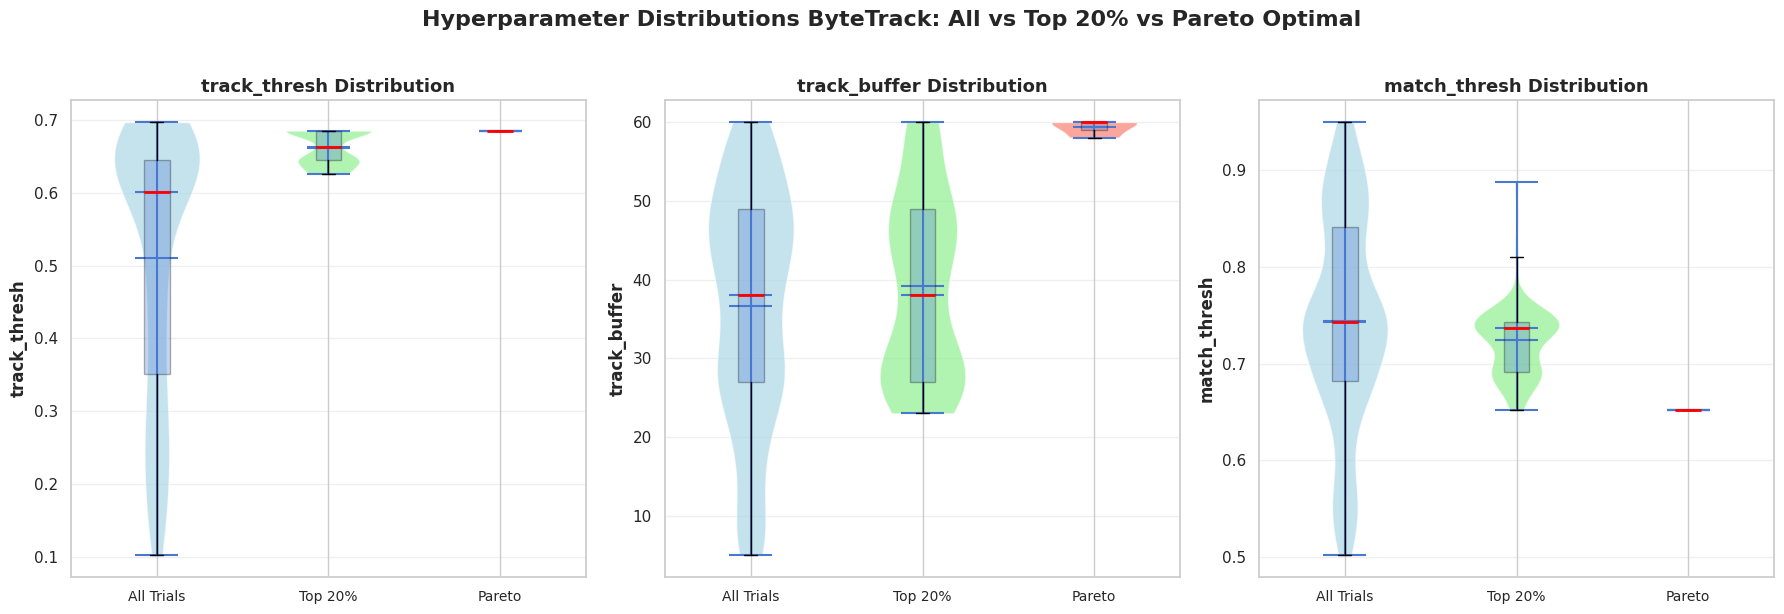

In [18]:
# Violin plots comparing All Trials vs Pareto Optimal vs Top 20% Combined
numerical_params = ['track_thresh', 'track_buffer', 'match_thresh']
top_20_pct = df_results.nlargest(int(len(df_results)*0.2), 'Combined')

fig, axes = plt.subplots(1, 3, figsize=(18, 6))
axes = axes.flatten()

for idx, param in enumerate(numerical_params):
    ax = axes[idx]
    
    # Prepare data for violin plot
    data_to_plot = [
        df_results[param],
        top_20_pct[param],
        pareto_trials[param]
    ]
    
    positions = [1, 2, 3]
    parts = ax.violinplot(data_to_plot, positions=positions, showmeans=True, showmedians=True, showextrema=True)
    
    # Customize colors
    colors = ['lightblue', 'lightgreen', 'salmon']
    for pc, color in zip(parts['bodies'], colors):
        pc.set_facecolor(color)
        pc.set_alpha(0.7)
    
    # Add box plots on top for better readability
    bp = ax.boxplot(data_to_plot, positions=positions, widths=0.15, 
                     patch_artist=True, showfliers=False,
                     boxprops=dict(alpha=0.3),
                     medianprops=dict(color='red', linewidth=2))
    
    ax.set_xticks(positions)
    ax.set_xticklabels(['All Trials', 'Top 20%', 'Pareto'], fontsize=10)
    ax.set_ylabel(param, fontsize=12, fontweight='bold')
    ax.set_title(f'{param} Distribution', fontsize=13, fontweight='bold')
    ax.grid(True, alpha=0.3, axis='y')

plt.suptitle('Hyperparameter Distributions ByteTrack: All vs Top 20% vs Pareto Optimal', 
             fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

## 7a. Optimal Hyperparameter Ranges - Violin Plots

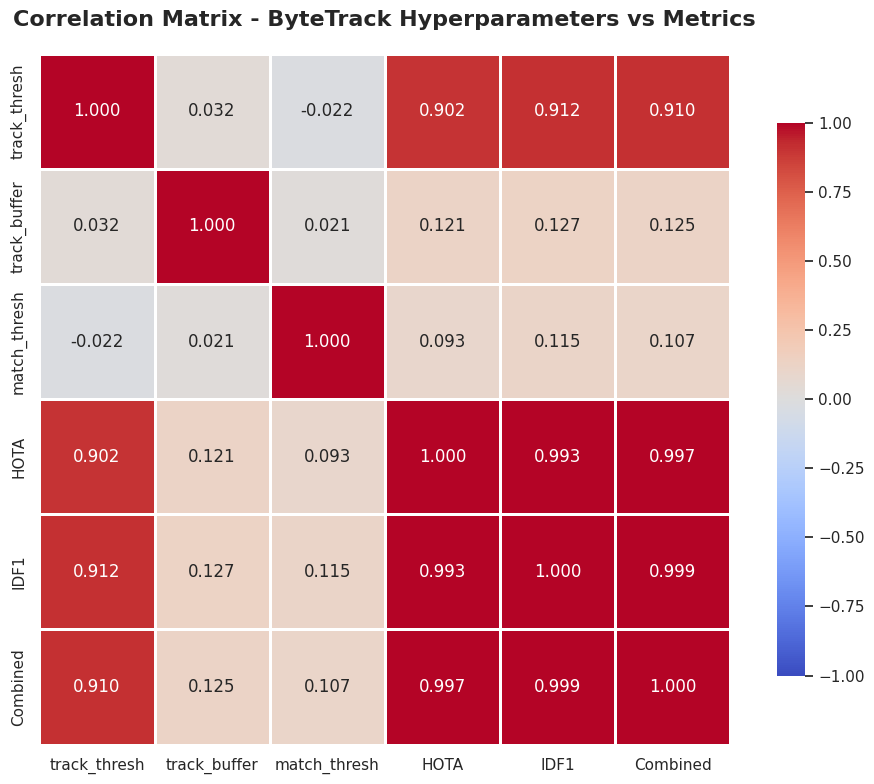


Key correlations:
  track_thresh vs HOTA: 0.9024
  track_thresh vs IDF1: 0.9124
  track_buffer vs HOTA: 0.1205
  track_buffer vs IDF1: 0.1269
  match_thresh vs HOTA: 0.0930
  match_thresh vs IDF1: 0.1150
  HOTA vs IDF1: 0.9932


In [13]:
# Correlation matrix
correlation_cols = ['track_thresh', 'track_buffer', 'match_thresh', 'HOTA', 'IDF1', 'Combined']
correlation_matrix = df_results[correlation_cols].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, fmt='.3f', cmap='coolwarm', 
            center=0, square=True, linewidths=2, cbar_kws={"shrink": 0.8},
            vmin=-1, vmax=1)
plt.title('Correlation Matrix - ByteTrack Hyperparameters vs Metrics', 
          fontsize=16, fontweight='bold', pad=20)
plt.tight_layout()
plt.show()

print("\nKey correlations:")
print(f"  track_thresh vs HOTA: {correlation_matrix.loc['track_thresh', 'HOTA']:.4f}")
print(f"  track_thresh vs IDF1: {correlation_matrix.loc['track_thresh', 'IDF1']:.4f}")
print(f"  track_buffer vs HOTA: {correlation_matrix.loc['track_buffer', 'HOTA']:.4f}")
print(f"  track_buffer vs IDF1: {correlation_matrix.loc['track_buffer', 'IDF1']:.4f}")
print(f"  match_thresh vs HOTA: {correlation_matrix.loc['match_thresh', 'HOTA']:.4f}")
print(f"  match_thresh vs IDF1: {correlation_matrix.loc['match_thresh', 'IDF1']:.4f}")
print(f"  HOTA vs IDF1: {correlation_matrix.loc['HOTA', 'IDF1']:.4f}")

## 9. Distribution Analysis

/tmp/ipykernel_67008/2997671096.py:29: MatplotlibDeprecationWarning:

The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.



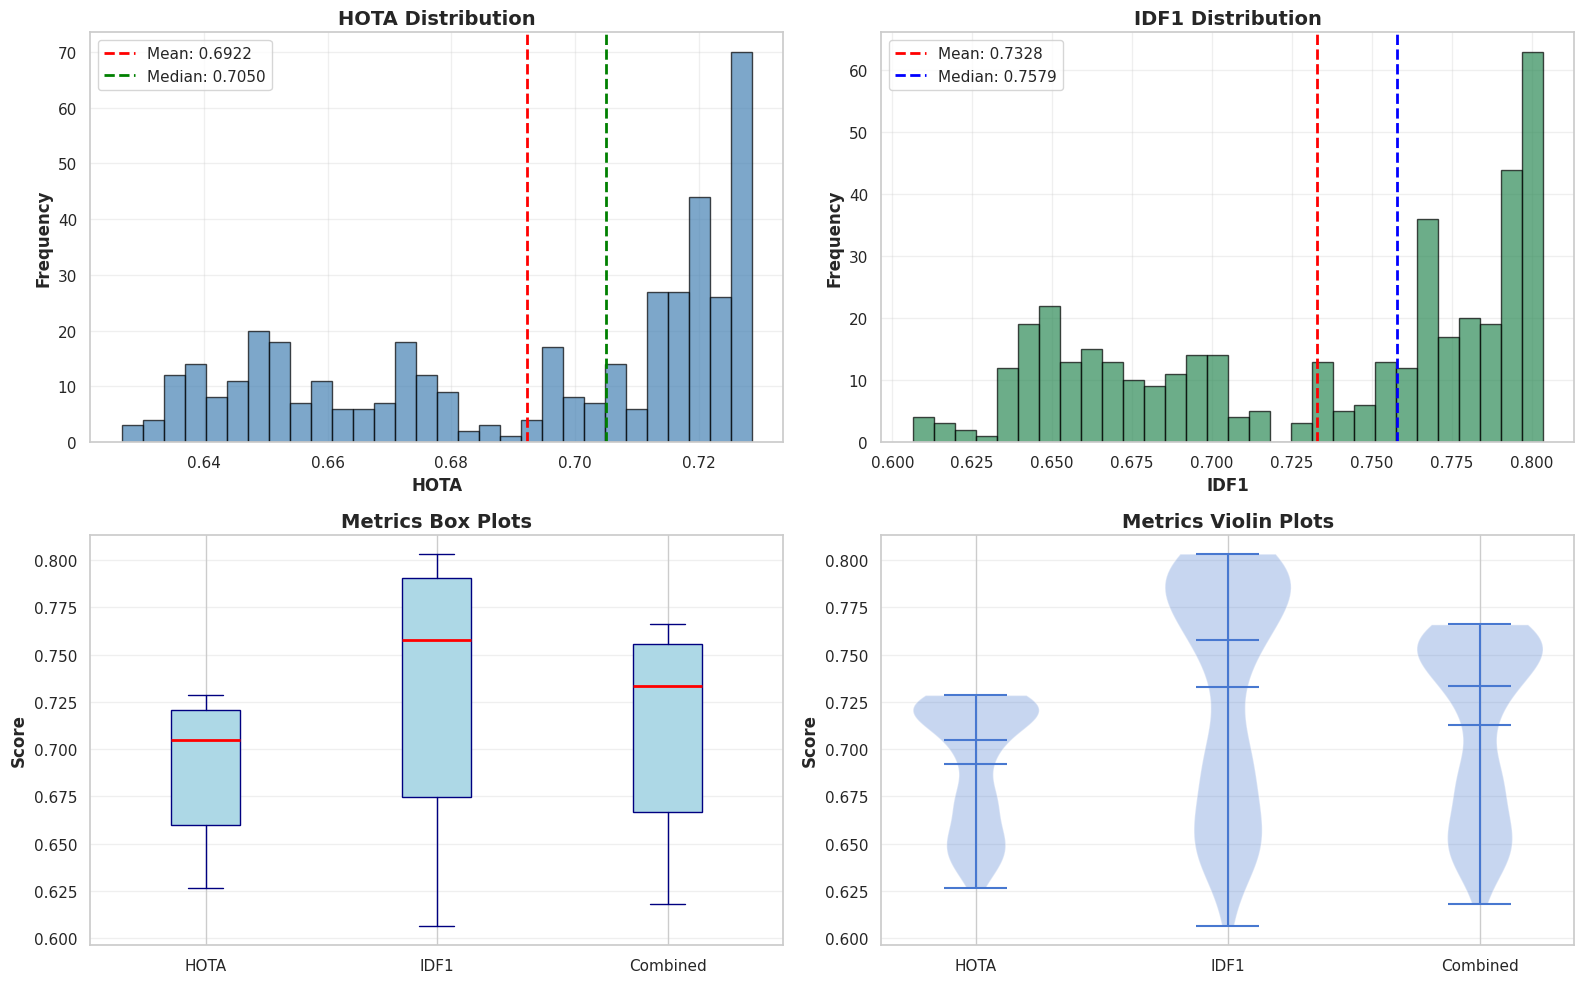

In [14]:
fig, axes = plt.subplots(2, 2, figsize=(16, 10))

# HOTA distribution
axes[0, 0].hist(df_results['HOTA'], bins=30, edgecolor='black', alpha=0.7, color='steelblue')
axes[0, 0].axvline(df_results['HOTA'].mean(), color='red', linestyle='--', linewidth=2, 
                   label=f'Mean: {df_results["HOTA"].mean():.4f}')
axes[0, 0].axvline(df_results['HOTA'].median(), color='green', linestyle='--', linewidth=2, 
                   label=f'Median: {df_results["HOTA"].median():.4f}')
axes[0, 0].set_xlabel('HOTA', fontsize=12, fontweight='bold')
axes[0, 0].set_ylabel('Frequency', fontsize=12, fontweight='bold')
axes[0, 0].set_title('HOTA Distribution', fontsize=14, fontweight='bold')
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3)

# IDF1 distribution
axes[0, 1].hist(df_results['IDF1'], bins=30, edgecolor='black', alpha=0.7, color='seagreen')
axes[0, 1].axvline(df_results['IDF1'].mean(), color='red', linestyle='--', linewidth=2, 
                   label=f'Mean: {df_results["IDF1"].mean():.4f}')
axes[0, 1].axvline(df_results['IDF1'].median(), color='blue', linestyle='--', linewidth=2, 
                   label=f'Median: {df_results["IDF1"].median():.4f}')
axes[0, 1].set_xlabel('IDF1', fontsize=12, fontweight='bold')
axes[0, 1].set_ylabel('Frequency', fontsize=12, fontweight='bold')
axes[0, 1].set_title('IDF1 Distribution', fontsize=14, fontweight='bold')
axes[0, 1].legend()
axes[0, 1].grid(True, alpha=0.3)

# Box plots
box_data = [df_results['HOTA'], df_results['IDF1'], df_results['Combined']]
axes[1, 0].boxplot(box_data, labels=['HOTA', 'IDF1', 'Combined'], patch_artist=True,
                   boxprops=dict(facecolor='lightblue', color='navy'),
                   medianprops=dict(color='red', linewidth=2),
                   whiskerprops=dict(color='navy'),
                   capprops=dict(color='navy'))
axes[1, 0].set_ylabel('Score', fontsize=12, fontweight='bold')
axes[1, 0].set_title('Metrics Box Plots', fontsize=14, fontweight='bold')
axes[1, 0].grid(True, alpha=0.3, axis='y')

# Violin plots
parts = axes[1, 1].violinplot(box_data, positions=[1, 2, 3], showmeans=True, showmedians=True)
axes[1, 1].set_xticks([1, 2, 3])
axes[1, 1].set_xticklabels(['HOTA', 'IDF1', 'Combined'])
axes[1, 1].set_ylabel('Score', fontsize=12, fontweight='bold')
axes[1, 1].set_title('Metrics Violin Plots', fontsize=14, fontweight='bold')
axes[1, 1].grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

## 10. Parameter Importance Analysis

/tmp/ipykernel_67008/670709796.py:2: FutureWarning:

The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.

/tmp/ipykernel_67008/670709796.py:3: FutureWarning:

The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.

/tmp/ipykernel_67008/670709796.py:4: FutureWarning:

The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.



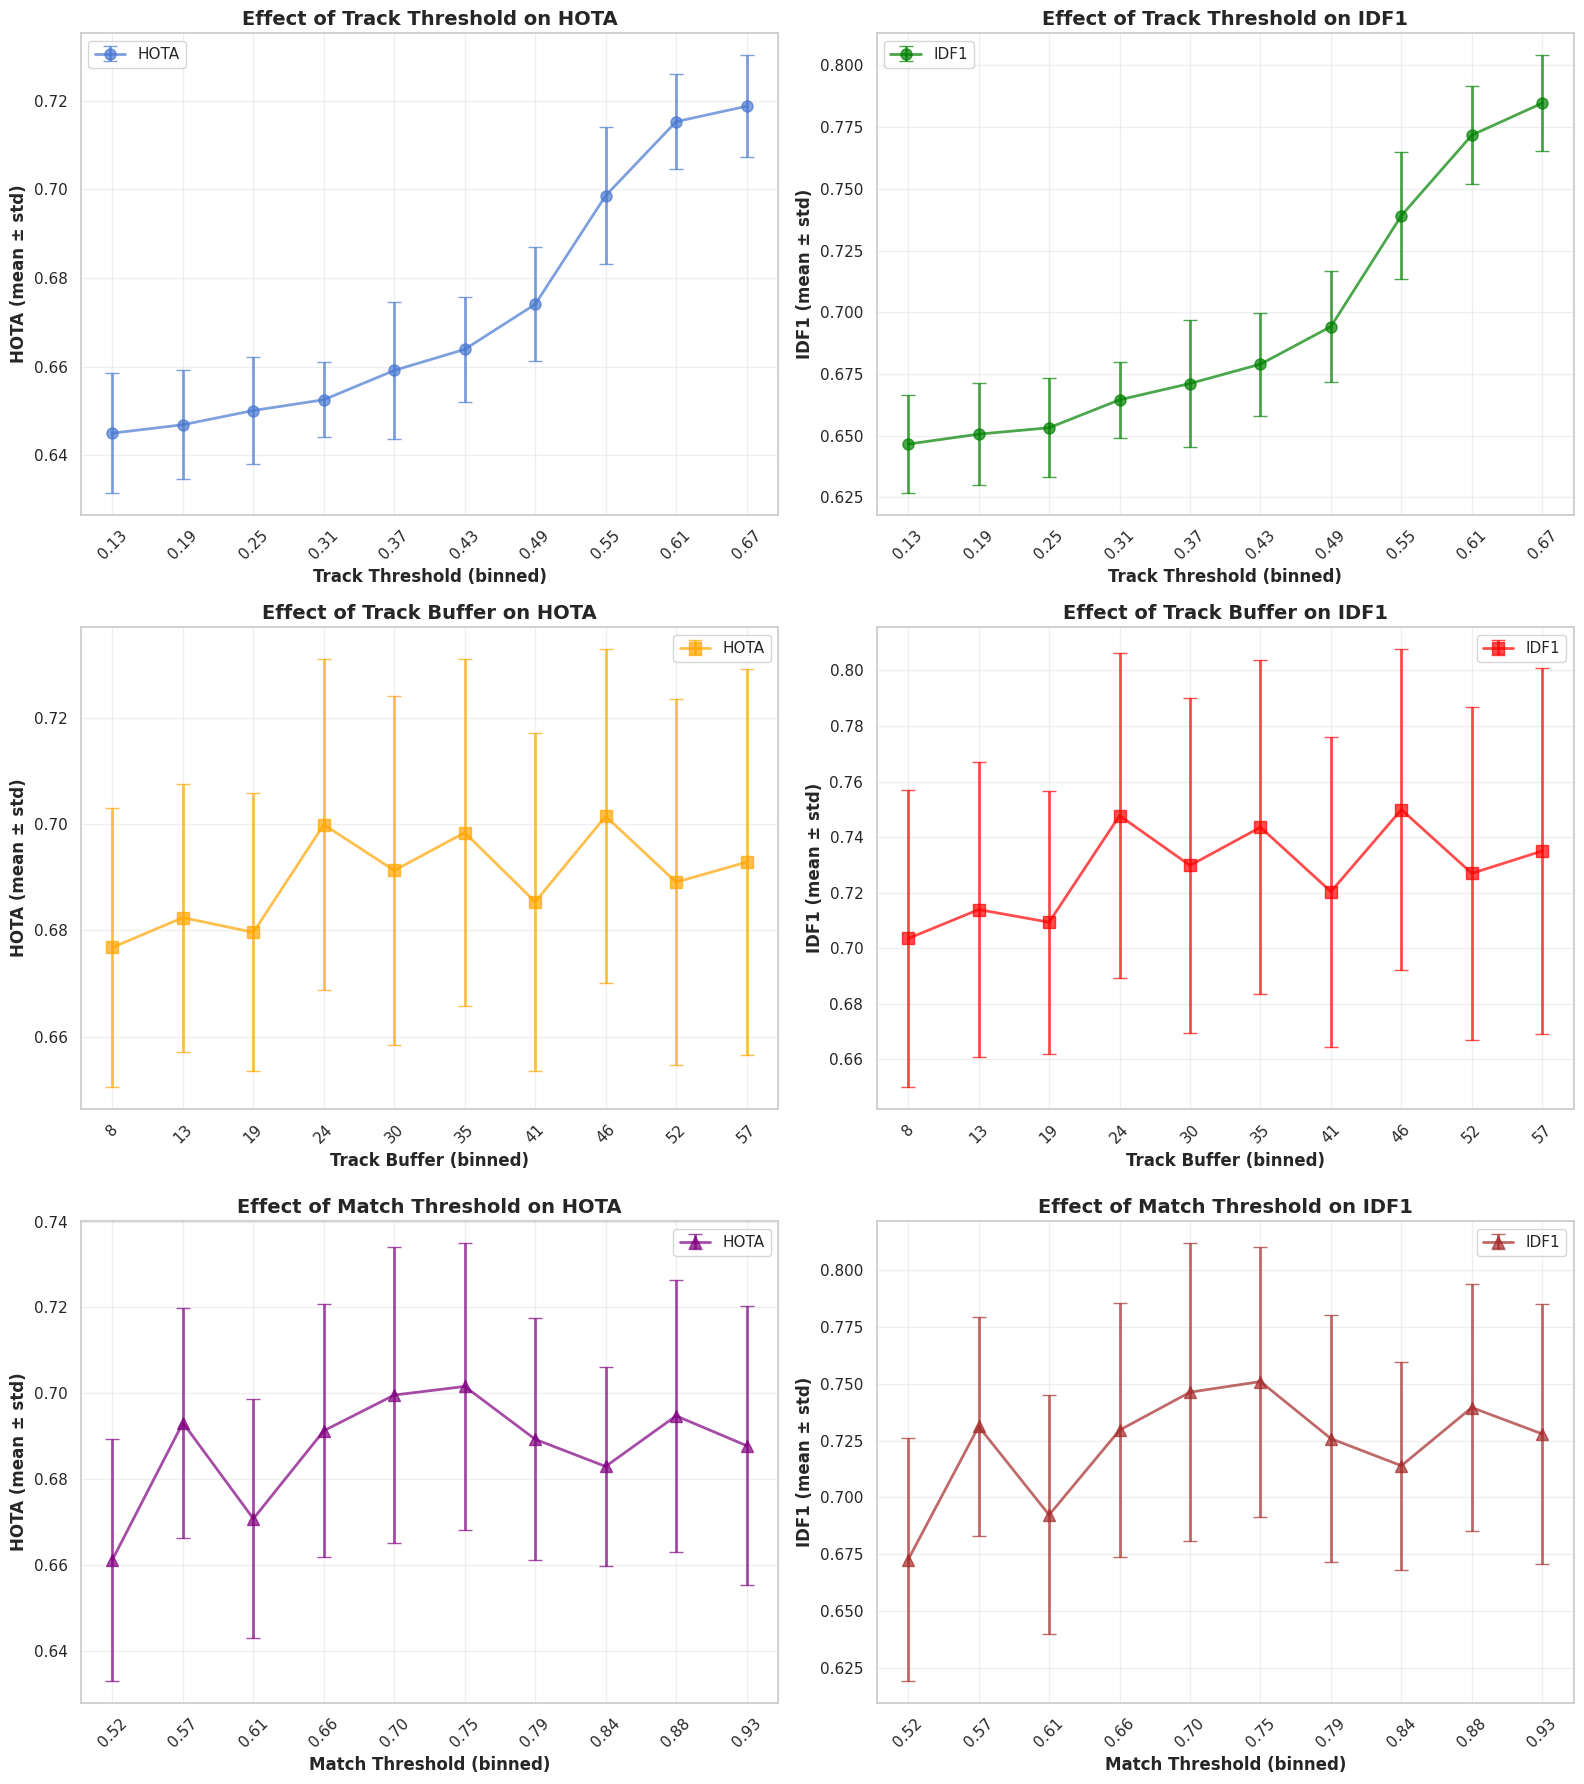

In [15]:
# Group by each parameter and calculate mean metrics
track_thresh_grouped = df_results.groupby(pd.cut(df_results['track_thresh'], bins=10))[['HOTA', 'IDF1', 'Combined']].agg(['mean', 'std', 'count'])
track_buffer_grouped = df_results.groupby(pd.cut(df_results['track_buffer'], bins=10))[['HOTA', 'IDF1', 'Combined']].agg(['mean', 'std', 'count'])
match_thresh_grouped = df_results.groupby(pd.cut(df_results['match_thresh'], bins=10))[['HOTA', 'IDF1', 'Combined']].agg(['mean', 'std', 'count'])

fig, axes = plt.subplots(3, 2, figsize=(16, 18))

# Track Thresh effect on HOTA
ax = axes[0, 0]
x_labels = [f"{interval.mid:.2f}" for interval in track_thresh_grouped.index]
ax.errorbar(range(len(track_thresh_grouped)), track_thresh_grouped['HOTA']['mean'], 
            yerr=track_thresh_grouped['HOTA']['std'], fmt='o-', linewidth=2, 
            markersize=8, capsize=5, label='HOTA', alpha=0.7)
ax.set_xticks(range(len(track_thresh_grouped)))
ax.set_xticklabels(x_labels, rotation=45)
ax.set_xlabel('Track Threshold (binned)', fontsize=12, fontweight='bold')
ax.set_ylabel('HOTA (mean ± std)', fontsize=12, fontweight='bold')
ax.set_title('Effect of Track Threshold on HOTA', fontsize=14, fontweight='bold')
ax.grid(True, alpha=0.3)
ax.legend()

# Track Thresh effect on IDF1
ax = axes[0, 1]
ax.errorbar(range(len(track_thresh_grouped)), track_thresh_grouped['IDF1']['mean'], 
            yerr=track_thresh_grouped['IDF1']['std'], fmt='o-', linewidth=2, 
            markersize=8, capsize=5, color='green', label='IDF1', alpha=0.7)
ax.set_xticks(range(len(track_thresh_grouped)))
ax.set_xticklabels(x_labels, rotation=45)
ax.set_xlabel('Track Threshold (binned)', fontsize=12, fontweight='bold')
ax.set_ylabel('IDF1 (mean ± std)', fontsize=12, fontweight='bold')
ax.set_title('Effect of Track Threshold on IDF1', fontsize=14, fontweight='bold')
ax.grid(True, alpha=0.3)
ax.legend()

# Track Buffer effect on HOTA
ax = axes[1, 0]
x_labels = [f"{interval.mid:.0f}" for interval in track_buffer_grouped.index]
ax.errorbar(range(len(track_buffer_grouped)), track_buffer_grouped['HOTA']['mean'], 
            yerr=track_buffer_grouped['HOTA']['std'], fmt='s-', linewidth=2, 
            markersize=8, capsize=5, color='orange', label='HOTA', alpha=0.7)
ax.set_xticks(range(len(track_buffer_grouped)))
ax.set_xticklabels(x_labels, rotation=45)
ax.set_xlabel('Track Buffer (binned)', fontsize=12, fontweight='bold')
ax.set_ylabel('HOTA (mean ± std)', fontsize=12, fontweight='bold')
ax.set_title('Effect of Track Buffer on HOTA', fontsize=14, fontweight='bold')
ax.grid(True, alpha=0.3)
ax.legend()

# Track Buffer effect on IDF1
ax = axes[1, 1]
ax.errorbar(range(len(track_buffer_grouped)), track_buffer_grouped['IDF1']['mean'], 
            yerr=track_buffer_grouped['IDF1']['std'], fmt='s-', linewidth=2, 
            markersize=8, capsize=5, color='red', label='IDF1', alpha=0.7)
ax.set_xticks(range(len(track_buffer_grouped)))
ax.set_xticklabels(x_labels, rotation=45)
ax.set_xlabel('Track Buffer (binned)', fontsize=12, fontweight='bold')
ax.set_ylabel('IDF1 (mean ± std)', fontsize=12, fontweight='bold')
ax.set_title('Effect of Track Buffer on IDF1', fontsize=14, fontweight='bold')
ax.grid(True, alpha=0.3)
ax.legend()

# Match Thresh effect on HOTA
ax = axes[2, 0]
x_labels = [f"{interval.mid:.2f}" for interval in match_thresh_grouped.index]
ax.errorbar(range(len(match_thresh_grouped)), match_thresh_grouped['HOTA']['mean'], 
            yerr=match_thresh_grouped['HOTA']['std'], fmt='^-', linewidth=2, 
            markersize=8, capsize=5, color='purple', label='HOTA', alpha=0.7)
ax.set_xticks(range(len(match_thresh_grouped)))
ax.set_xticklabels(x_labels, rotation=45)
ax.set_xlabel('Match Threshold (binned)', fontsize=12, fontweight='bold')
ax.set_ylabel('HOTA (mean ± std)', fontsize=12, fontweight='bold')
ax.set_title('Effect of Match Threshold on HOTA', fontsize=14, fontweight='bold')
ax.grid(True, alpha=0.3)
ax.legend()

# Match Thresh effect on IDF1
ax = axes[2, 1]
ax.errorbar(range(len(match_thresh_grouped)), match_thresh_grouped['IDF1']['mean'], 
            yerr=match_thresh_grouped['IDF1']['std'], fmt='^-', linewidth=2, 
            markersize=8, capsize=5, color='brown', label='IDF1', alpha=0.7)
ax.set_xticks(range(len(match_thresh_grouped)))
ax.set_xticklabels(x_labels, rotation=45)
ax.set_xlabel('Match Threshold (binned)', fontsize=12, fontweight='bold')
ax.set_ylabel('IDF1 (mean ± std)', fontsize=12, fontweight='bold')
ax.set_title('Effect of Match Threshold on IDF1', fontsize=14, fontweight='bold')
ax.grid(True, alpha=0.3)
ax.legend()

plt.tight_layout()
plt.show()

## 11. Top Configurations

In [16]:
print("="*80)
print("TOP 10 CONFIGURATIONS")
print("="*80)

print("\nBy HOTA:")
top_hota = df_results.nlargest(10, 'HOTA')[['trial_id', 'track_thresh', 'track_buffer', 'match_thresh', 'HOTA', 'IDF1', 'Combined']]
print(top_hota.to_string(index=False))

print("\n" + "-"*80)
print("\nBy IDF1:")
top_idf1 = df_results.nlargest(10, 'IDF1')[['trial_id', 'track_thresh', 'track_buffer', 'match_thresh', 'HOTA', 'IDF1', 'Combined']]
print(top_idf1.to_string(index=False))

print("\n" + "-"*80)
print("\nBy Combined Score:")
top_combined = df_results.nlargest(10, 'Combined')[['trial_id', 'track_thresh', 'track_buffer', 'match_thresh', 'HOTA', 'IDF1', 'Combined']]
print(top_combined.to_string(index=False))

TOP 10 CONFIGURATIONS

By HOTA:
 trial_id  track_thresh  track_buffer  match_thresh     HOTA     IDF1  Combined
      144      0.685907          60.0      0.651925 0.728559 0.803272  0.765915
      719      0.685907          60.0      0.651925 0.728559 0.803272  0.765915
     1014      0.685907          58.0      0.651925 0.728559 0.803272  0.765915
     1034      0.629065          47.0      0.736501 0.727989 0.800896  0.764442
     1093      0.644523          24.0      0.682197 0.727937 0.798530  0.763234
     1005      0.644523          24.0      0.691484 0.727879 0.798462  0.763171
      558      0.662784          50.0      0.691484 0.727806 0.801846  0.764826
     1087      0.662784          50.0      0.691484 0.727806 0.801846  0.764826
     1102      0.662784          50.0      0.691484 0.727806 0.801846  0.764826
      963      0.685907          27.0      0.668848 0.727800 0.801022  0.764411

--------------------------------------------------------------------------------

By ID

## 12. Summary and Recommendations

In [17]:
print("="*80)
print("BYTETRACK - SUMMARY AND RECOMMENDATIONS")
print("="*80)

best_combined_trial = df_results.loc[df_results['Combined'].idxmax()]

print("\n🏆 RECOMMENDED CONFIGURATION (Best Combined Score):")
print(f"  - Track Threshold: {best_combined_trial['track_thresh']:.4f}")
print(f"  - Track Buffer: {int(best_combined_trial['track_buffer'])}")
print(f"  - Match Threshold: {best_combined_trial['match_thresh']:.4f}")
print(f"  - HOTA: {best_combined_trial['HOTA']:.4f}")
print(f"  - IDF1: {best_combined_trial['IDF1']:.4f}")
print(f"  - Combined: {best_combined_trial['Combined']:.4f}")

print("\n📊 Key Findings:")
print(f"  • Total trials evaluated: {len(df_results)}")
print(f"  • Pareto optimal solutions: {len(pareto_trials)}")
print(f"  • HOTA range: [{df_results['HOTA'].min():.4f}, {df_results['HOTA'].max():.4f}]")
print(f"  • IDF1 range: [{df_results['IDF1'].min():.4f}, {df_results['IDF1'].max():.4f}]")

print("\n🔍 Parameter Insights:")
hota_top20_pct = df_results.nlargest(int(len(df_results)*0.2), 'HOTA')
idf1_top20_pct = df_results.nlargest(int(len(df_results)*0.2), 'IDF1')

print(f"  • Best Track Threshold range (top 20% HOTA): [{hota_top20_pct['track_thresh'].min():.2f}, {hota_top20_pct['track_thresh'].max():.2f}]")
print(f"  • Best Track Buffer range (top 20% HOTA): [{hota_top20_pct['track_buffer'].min():.0f}, {hota_top20_pct['track_buffer'].max():.0f}]")
print(f"  • Best Match Threshold range (top 20% HOTA): [{hota_top20_pct['match_thresh'].min():.2f}, {hota_top20_pct['match_thresh'].max():.2f}]")

print("\n✅ Analysis Complete!")

BYTETRACK - SUMMARY AND RECOMMENDATIONS

🏆 RECOMMENDED CONFIGURATION (Best Combined Score):
  - Track Threshold: 0.6859
  - Track Buffer: 60
  - Match Threshold: 0.6519
  - HOTA: 0.7286
  - IDF1: 0.8033
  - Combined: 0.7659

📊 Key Findings:
  • Total trials evaluated: 422
  • Pareto optimal solutions: 3
  • HOTA range: [0.6267, 0.7286]
  • IDF1 range: [0.6064, 0.8033]

🔍 Parameter Insights:
  • Best Track Threshold range (top 20% HOTA): [0.63, 0.69]
  • Best Track Buffer range (top 20% HOTA): [23, 60]
  • Best Match Threshold range (top 20% HOTA): [0.65, 0.82]

✅ Analysis Complete!
